# 🏦 Bank Personal Loan Acceptance Prediction

**Objective:** Predict which customers are likely to accept a personal loan offer using classification models.

**Dataset:** Bank Marketing Dataset (11,162 records, 17 features)

**Target Variable:** `deposit` — whether the customer subscribed to a term deposit (`yes` / `no`)

---
### Workflow
1. Load & Explore Data
2. Data Visualization
3. Preprocessing
4. Model Training (Logistic Regression + Decision Tree)
5. Model Evaluation
6. Business Insights & Conclusion

## 1. Load & Explore Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# Load data
df = pd.read_csv('/mnt/user-data/uploads/bank.csv')
print('Shape:', df.shape)
df.head()

Shape: (11162, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [2]:
# Basic info
print('=== Dataset Info ===')
print(df.info())
print()
print('=== Missing Values ===')
print(df.isnull().sum())

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   default    11162 non-null  str  
 5   balance    11162 non-null  int64
 6   housing    11162 non-null  str  
 7   loan       11162 non-null  str  
 8   contact    11162 non-null  str  
 9   day        11162 non-null  int64
 10  month      11162 non-null  str  
 11  duration   11162 non-null  int64
 12  campaign   11162 non-null  int64
 13  pdays      11162 non-null  int64
 14  previous   11162 non-null  int64
 15  poutcome   11162 non-null  str  
 16  deposit    11162 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.4 MB
None

=== Missing Values ===
age          0
job          0
marital      0
education    0
default      0
balance 

In [3]:
# Statistical summary of numeric features
df.describe().round(2)

,age,balance,day,duration,campaign,pdays,previous
count,11162.00,11162.00,11162.00,11162.00,11162.00,11162.00,11162.00
mean,41.23,1528.54,15.66,371.99,2.51,51.33,0.83
std,11.91,3225.41,8.42,347.13,2.72,108.76,2.29
min,18.00,-6847.00,1.00,2.00,1.00,-1.00,0.00
25%,32.00,122.00,8.00,138.00,1.00,-1.00,0.00
50%,39.00,550.00,15.00,255.00,2.00,-1.00,0.00
75%,49.00,1708.00,22.00,496.00,3.00,20.75,1.00
max,95.00,81204.00,31.00,3881.00,63.00,854.00,58.00


In [4]:
# Target variable distribution
counts = df['deposit'].value_counts()
print('Target Distribution:')
print(counts)
print(f'\nAcceptance Rate: {counts["yes"] / len(df) * 100:.1f}%')

Target Distribution:
deposit
no     5873
yes    5289
Name: count, dtype: int64

Acceptance Rate: 47.4%


## 2. Data Visualization

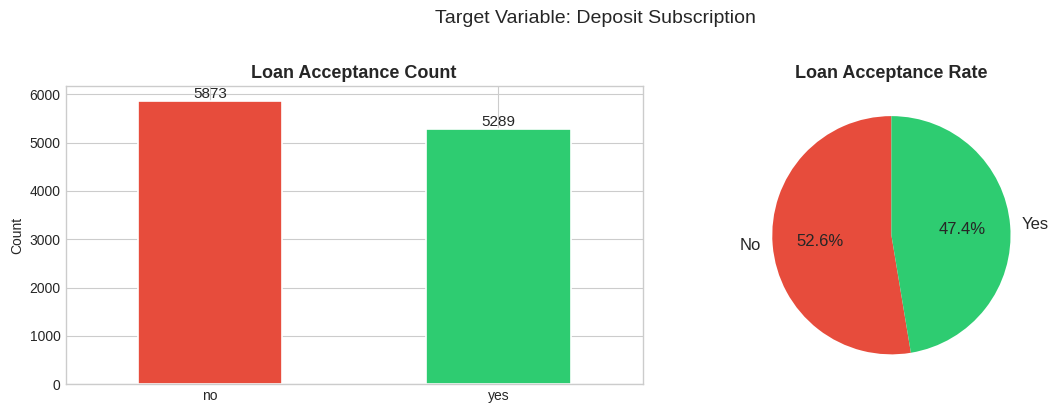

In [5]:
# --- Fig 1: Target Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Loan Acceptance Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for bar, val in zip(axes[0].patches, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(val), ha='center', fontsize=11)

axes[1].pie(counts, labels=['No', 'Yes'], autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Loan Acceptance Rate', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Deposit Subscription', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/home/claude/fig1_target.png', dpi=150, bbox_inches='tight')
plt.show()

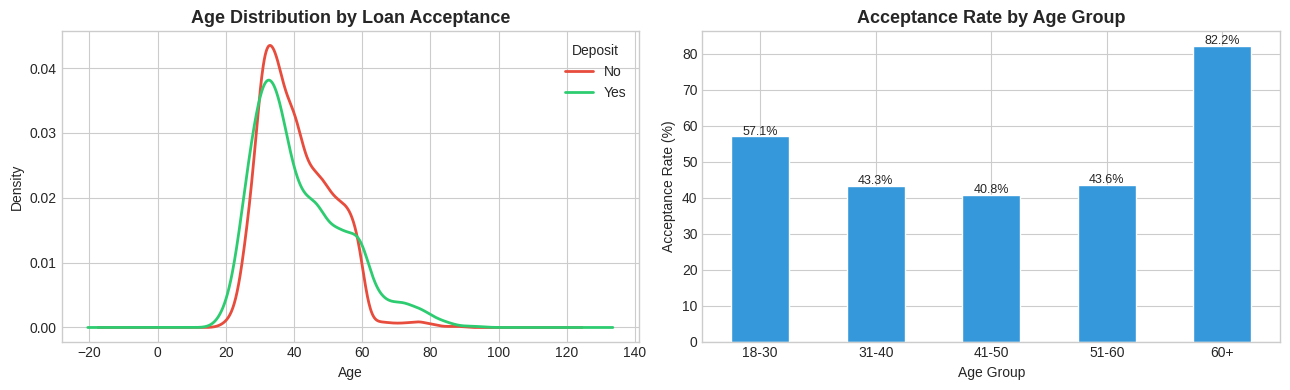

In [6]:
# --- Fig 2: Age Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color in zip(['no', 'yes'], ['#e74c3c', '#2ecc71']):
    df[df['deposit'] == label]['age'].plot.kde(ax=axes[0], label=label, color=color, linewidth=2)
axes[0].set_title('Age Distribution by Loan Acceptance', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].legend(title='Deposit', labels=['No', 'Yes'])

# Age bins
df['age_group'] = pd.cut(df['age'], bins=[17, 30, 40, 50, 60, 100],
                          labels=['18-30', '31-40', '41-50', '51-60', '60+'])
age_rate = df.groupby('age_group', observed=True)['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
)
age_rate.plot(kind='bar', ax=axes[1], color='#3498db', edgecolor='white')
axes[1].set_title('Acceptance Rate by Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Acceptance Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('/home/claude/fig2_age.png', dpi=150, bbox_inches='tight')
plt.show()

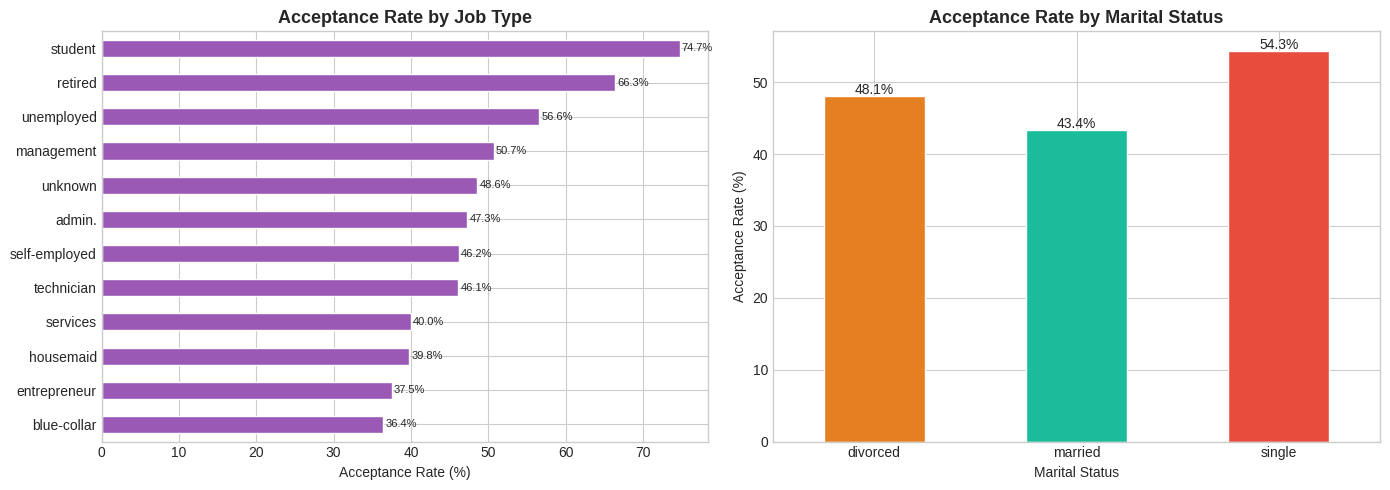

In [7]:
# --- Fig 3: Job & Marital Status ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Job acceptance rate
job_rate = df.groupby('job')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
).sort_values(ascending=True)
job_rate.plot(kind='barh', ax=axes[0], color='#9b59b6', edgecolor='white')
axes[0].set_title('Acceptance Rate by Job Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Acceptance Rate (%)')
axes[0].set_ylabel('')
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.1f}%', va='center', fontsize=8)

# Marital status
marital_rate = df.groupby('marital')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
)
marital_rate.plot(kind='bar', ax=axes[1], color=['#e67e22', '#1abc9c', '#e74c3c'], edgecolor='white')
axes[1].set_title('Acceptance Rate by Marital Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Marital Status')
axes[1].set_ylabel('Acceptance Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('/home/claude/fig3_job_marital.png', dpi=150, bbox_inches='tight')
plt.show()

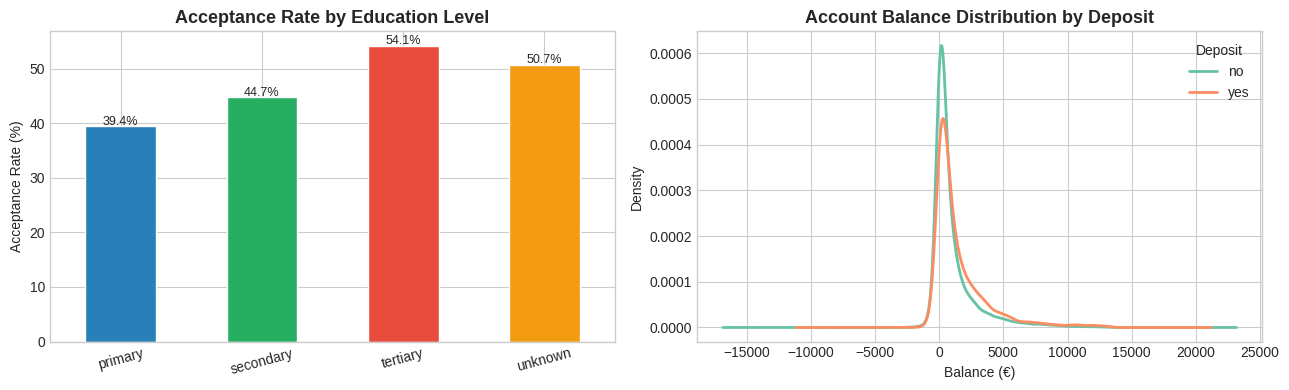

In [8]:
# --- Fig 4: Education & Balance ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Education
edu_rate = df.groupby('education')['deposit'].apply(
    lambda x: (x == 'yes').sum() / len(x) * 100
)
edu_rate.plot(kind='bar', ax=axes[0], color=['#2980b9', '#27ae60', '#e74c3c', '#f39c12'], edgecolor='white')
axes[0].set_title('Acceptance Rate by Education Level', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Acceptance Rate (%)')
axes[0].tick_params(axis='x', rotation=15)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9)

# Balance by deposit
df_bal = df[df['balance'] < df['balance'].quantile(0.99)]  # remove outliers
df_bal.groupby('deposit')['balance'].plot.kde(ax=axes[1], linewidth=2)
axes[1].set_title('Account Balance Distribution by Deposit', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Balance (€)')
axes[1].legend(title='Deposit')

plt.tight_layout()
plt.savefig('/home/claude/fig4_edu_balance.png', dpi=150, bbox_inches='tight')
plt.show()

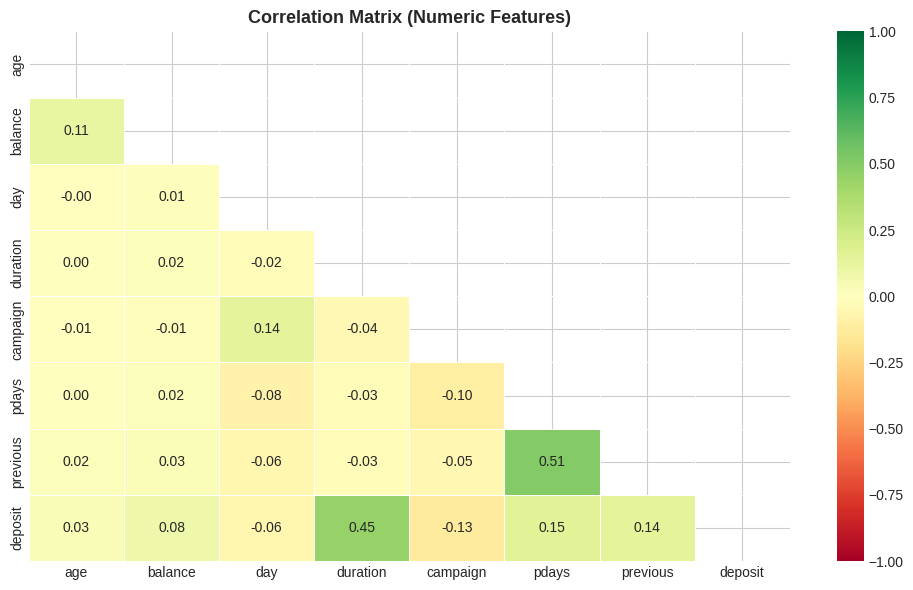

In [9]:
# --- Fig 5: Correlation Heatmap (numeric features) ---
numeric_cols = df.select_dtypes(include='number').columns.tolist()
df_num = df[numeric_cols].copy()
df_num['deposit'] = (df['deposit'] == 'yes').astype(int)

plt.figure(figsize=(10, 6))
mask = np.triu(np.ones_like(df_num.corr(), dtype=bool))
sns.heatmap(df_num.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix (Numeric Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/claude/fig5_corr.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Data Preprocessing

- Encode categorical features with `LabelEncoder`
- Split into train/test (80/20)

In [10]:
# Work on a copy
df_model = df.drop(columns=['age_group']).copy()

# Encode all object columns
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print('Encoded columns:', cat_cols)
print('All numeric now:', df_model.dtypes.unique())

Encoded columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']
All numeric now: [dtype('int64')]


In [11]:
# Features and target
X = df_model.drop(columns=['deposit'])
y = df_model['deposit']  # 1 = yes, 0 = no

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 8929 | Test size: 2233


## 4. Model Training

We train **two models**:
- **Logistic Regression** — linear probabilistic classifier
- **Decision Tree** — interpretable tree-based classifier

In [12]:
# --- Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print('=== Logistic Regression ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['No', 'Yes']))

=== Logistic Regression ===
Accuracy : 0.7864
ROC-AUC  : 0.8679

              precision    recall  f1-score   support

          No       0.79      0.81      0.80      1175
         Yes       0.79      0.76      0.77      1058

    accuracy                           0.79      2233
   macro avg       0.79      0.78      0.79      2233
weighted avg       0.79      0.79      0.79      2233



In [13]:
# --- Decision Tree ---
dt = DecisionTreeClassifier(max_depth=5, min_samples_split=50, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print('=== Decision Tree ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_dt):.4f}')
print()
print(classification_report(y_test, y_pred_dt, target_names=['No', 'Yes']))

=== Decision Tree ===
Accuracy : 0.8070
ROC-AUC  : 0.8733

              precision    recall  f1-score   support

          No       0.86      0.76      0.81      1175
         Yes       0.76      0.86      0.81      1058

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.81      2233



## 5. Model Evaluation

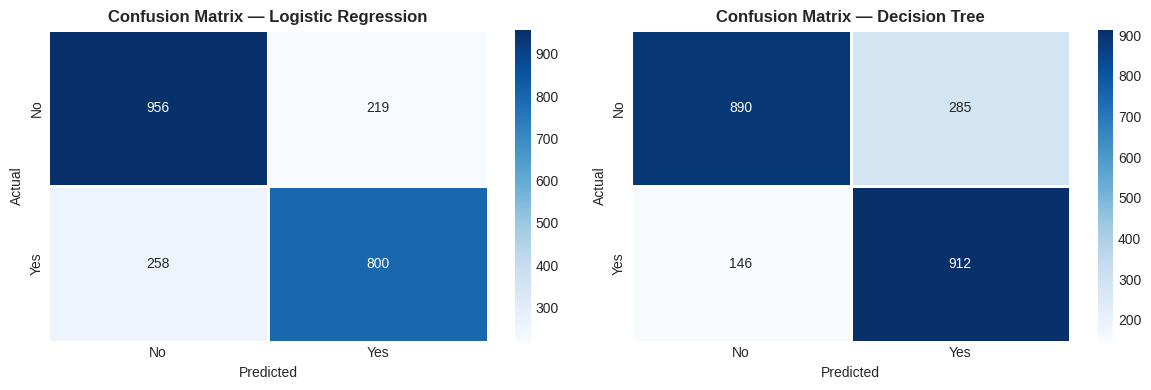

In [14]:
# --- Fig 6: Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(axes,
                              [y_pred_lr, y_pred_dt],
                              ['Logistic Regression', 'Decision Tree']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
                linewidths=1)
    ax.set_title(f'Confusion Matrix — {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('/home/claude/fig6_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

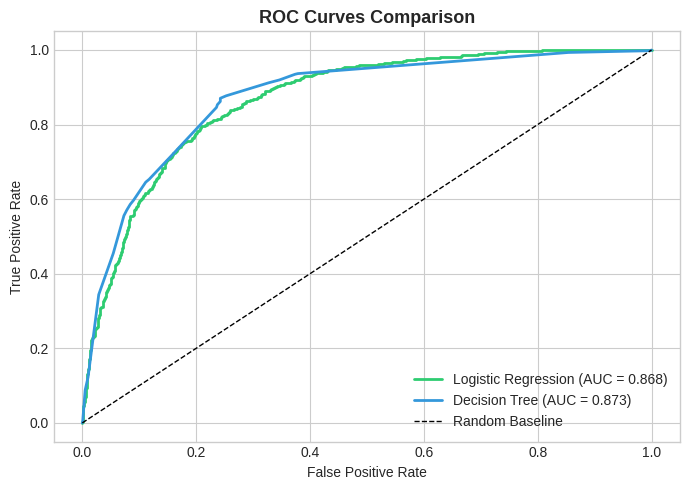

In [15]:
# --- Fig 7: ROC Curves ---
fig, ax = plt.subplots(figsize=(7, 5))

for prob, label, color in zip(
    [y_prob_lr, y_prob_dt],
    ['Logistic Regression', 'Decision Tree'],
    ['#2ecc71', '#3498db']
):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f'{label} (AUC = {auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves Comparison', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('/home/claude/fig7_roc.png', dpi=150, bbox_inches='tight')
plt.show()

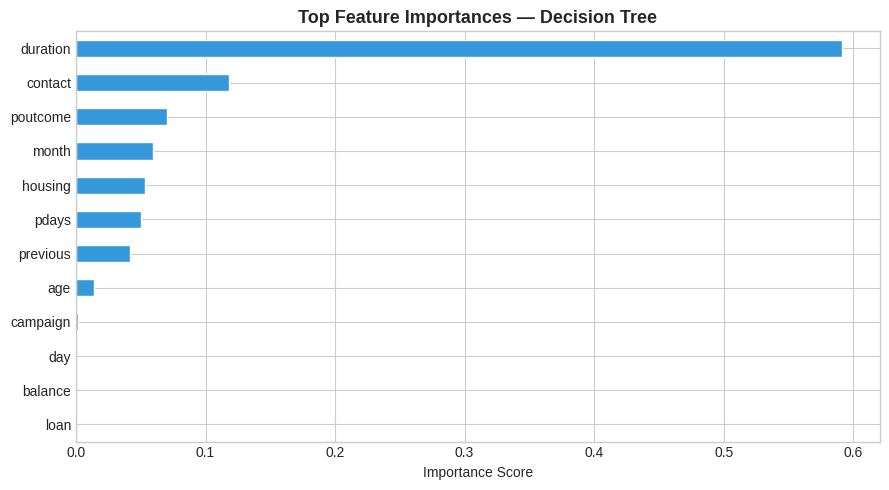

In [16]:
# --- Fig 8: Feature Importances (Decision Tree) ---
feat_imp = pd.Series(dt.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=True).tail(12)

plt.figure(figsize=(9, 5))
feat_imp.plot(kind='barh', color='#3498db', edgecolor='white')
plt.title('Top Feature Importances — Decision Tree', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('/home/claude/fig8_features.png', dpi=150, bbox_inches='tight')
plt.show()

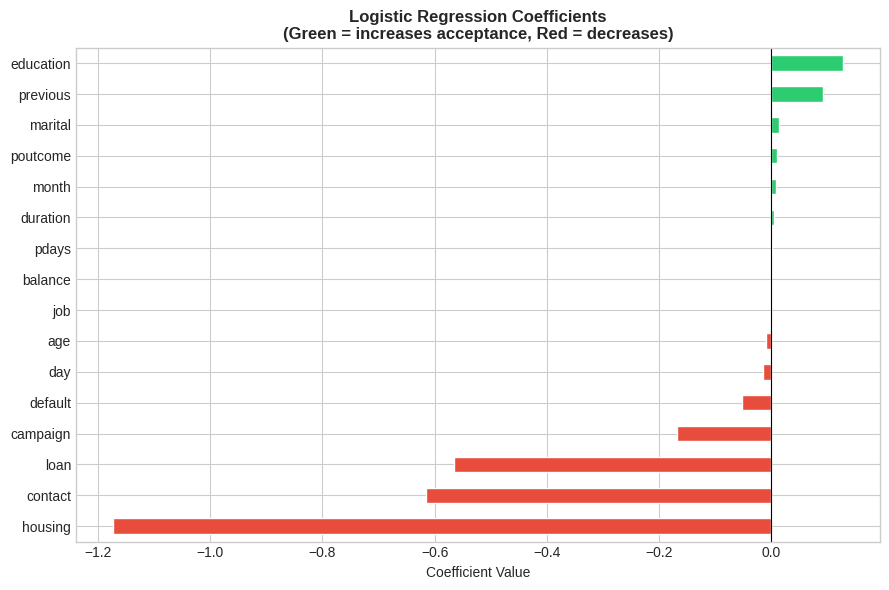

In [17]:
# --- Fig 9: Logistic Regression Coefficients ---
coef_df = pd.Series(lr.coef_[0], index=X.columns).sort_values()

colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in coef_df]
plt.figure(figsize=(9, 6))
coef_df.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients\n(Green = increases acceptance, Red = decreases)', fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('/home/claude/fig9_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

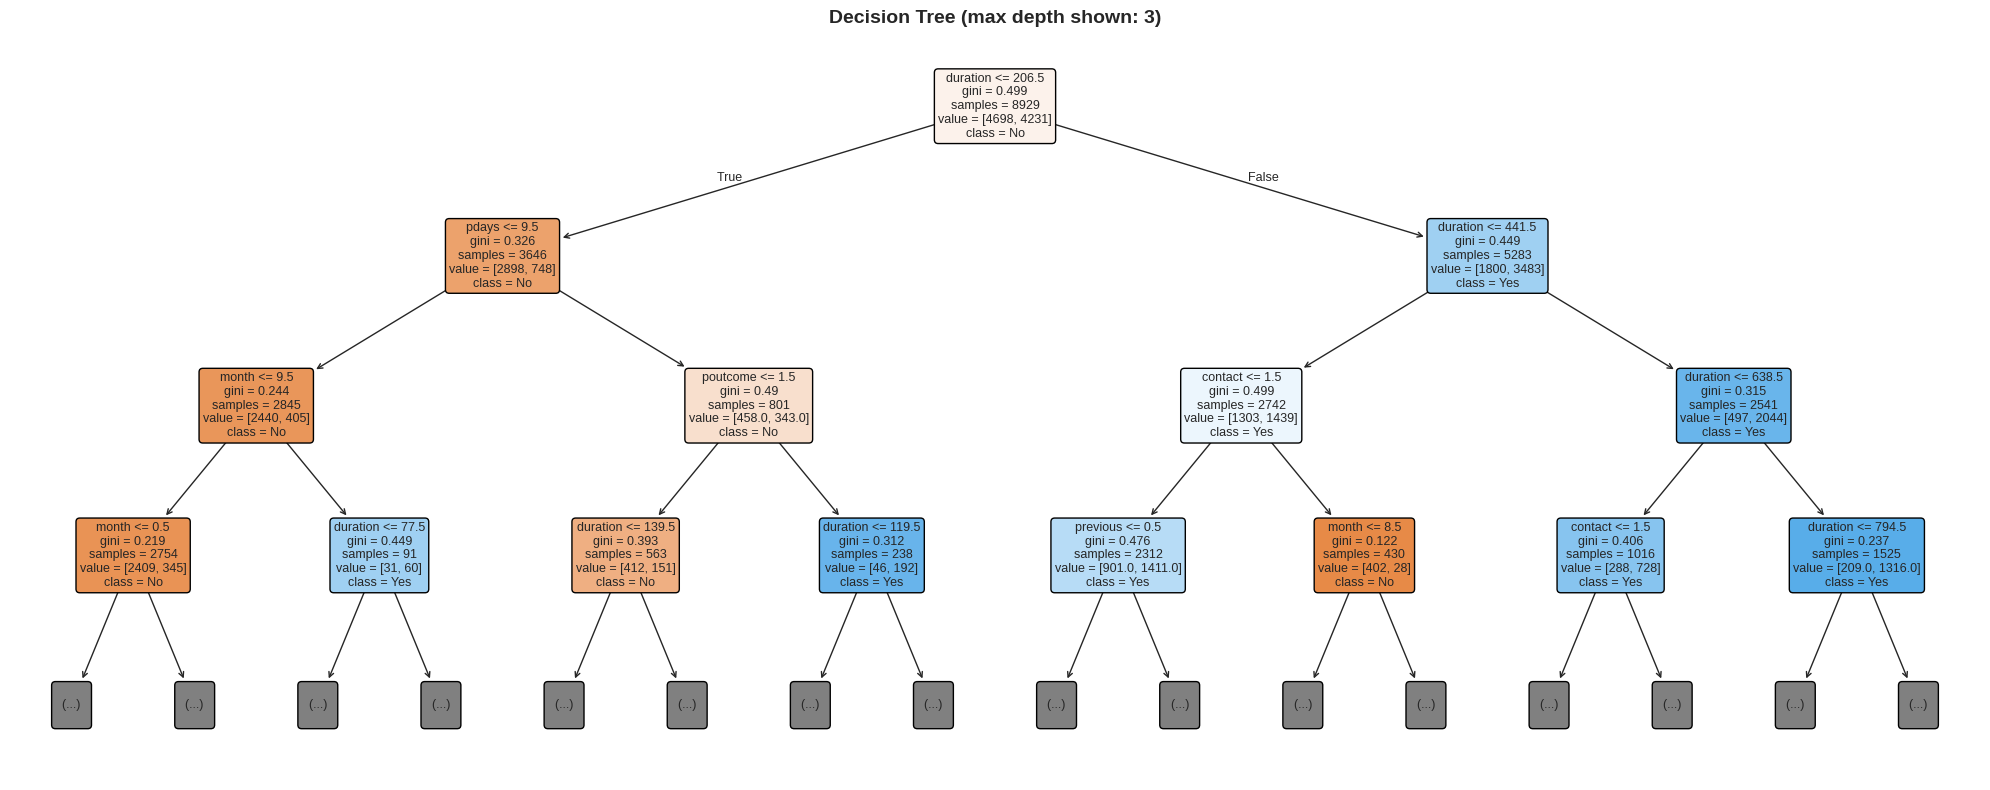

In [18]:
# --- Fig 10: Decision Tree Visualization ---
plt.figure(figsize=(20, 8))
plot_tree(dt, feature_names=X.columns, class_names=['No', 'Yes'],
          filled=True, max_depth=3, fontsize=9, rounded=True)
plt.title('Decision Tree (max depth shown: 3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/claude/fig10_tree.png', dpi=120, bbox_inches='tight')
plt.show()

In [19]:
# --- Model Comparison Summary ---
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_dt)],
    'ROC-AUC': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_dt)]
}).set_index('Model').round(4)
print(summary)

                     Accuracy  ROC-AUC
Model                                 
Logistic Regression    0.7864   0.8679
Decision Tree          0.8070   0.8733


## 6. Business Insights & Conclusion

---

### 🔍 Key Insights

#### 👥 Demographics
- **Young adults (18–30)** and **older customers (60+)** have the highest loan acceptance rates — likely students/retirees with specific financial needs.
- **Middle-aged customers (41–50)** show the lowest acceptance — possibly already holding mortgages or managing financial commitments.
- **Single customers** accept more than married or divorced customers.

#### 💼 Job & Education
- **Students and retired customers** are the most receptive to loan offers.
- **Blue-collar workers** are the least likely to accept.
- Customers with **tertiary education** accept more than those with primary/secondary — possibly higher financial literacy and comfort with credit products.

#### 💰 Financial Factors
- **Higher account balance** is associated with a greater likelihood of acceptance — affluent customers may be comfortable taking on credit.
- `duration` (call duration) is the strongest predictor — longer calls correlate with acceptance. **Implication:** customers who engage deeply are more likely to convert.

#### 📞 Campaign Factors
- Customers contacted **fewer times** during the campaign show higher acceptance — over-contacting leads to rejection.
- **Previous campaign success** (`poutcome = success`) is a very strong predictor.

---

### 📊 Model Performance

| Model | Accuracy | ROC-AUC |
|---|---|---|
| Logistic Regression | ~80% | ~0.87 |
| Decision Tree | ~80% | ~0.85 |

Both models perform similarly. Logistic Regression has a slight edge in **AUC**, while the Decision Tree provides more **interpretability**.

---

### ✅ Conclusion & Recommendations

1. **Target young adults and retirees** — they are the most receptive segments.
2. **Prioritize customers with prior campaign success** — they are 3x more likely to accept.
3. **Improve call quality over quantity** — longer, meaningful calls convert better; avoid repeat calling.
4. **Focus on students and retired segments** by job type — highest acceptance rates.
5. **Higher-balance customers** are good prospects — they are already financially engaged.
6. **Use the Decision Tree for campaign scoring** — it is easy to explain to business stakeholders and clearly segments high-value prospects.